In [ ]:
# Title: Where Defenses Break and Attacks Convert: An xG Analysis of the 2025/26 Premier League
# Group number: 21
# Group members: Luke DeFrance, Bach Pham, Faraz Behlum, Allan Biju Gregory

In [58]:
!pip install mplsoccer

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap
from mplsoccer import Pitch

In [60]:
shotsdf = pd.read_csv("pl_2025_shots.csv")
shotsdf.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,637500,2,SavedShot,0.762,0.699,0.014601,Hugo Ekitike,h,8995,OpenPlay,2025,RightFoot,28778,Liverpool,Bournemouth,4,2,2025-08-15 19:00:00,Cody Gakpo,Pass
1,637501,3,SavedShot,0.856,0.313,0.042656,Mohamed Salah,h,1250,OpenPlay,2025,LeftFoot,28778,Liverpool,Bournemouth,4,2,2025-08-15 19:00:00,Hugo Ekitike,Pass
2,637502,4,MissedShots,0.914,0.505,0.257975,Virgil van Dijk,h,833,FromCorner,2025,Head,28778,Liverpool,Bournemouth,4,2,2025-08-15 19:00:00,Mohamed Salah,Cross
3,637505,30,SavedShot,0.912,0.532,0.077662,Virgil van Dijk,h,833,FromCorner,2025,Head,28778,Liverpool,Bournemouth,4,2,2025-08-15 19:00:00,Florian Wirtz,Cross
4,637507,36,Goal,0.891,0.524,0.404091,Hugo Ekitike,h,8995,OpenPlay,2025,RightFoot,28778,Liverpool,Bournemouth,4,2,2025-08-15 19:00:00,Alexis Mac Allister,TakeOn


In [61]:
# Drop unnecessary columns for the work we're doing and also filter out penalty shots as 
# these heavily skew the data without telling us much about the team's defense/offense
noPenShotsdf = shotsdf[shotsdf['situation'] != 'Penalty']
cols_to_drop = ['lastAction', 'player_assisted', 'date', 'a_goals', 'h_goals', 'match_id', 'shotType', 'minute']
noPenShotsdf = noPenShotsdf.drop(columns=cols_to_drop)
noPenShotsdf.head()

,id,result,X,Y,xG,player,h_a,player_id,situation,season,h_team,a_team
0,637500,SavedShot,0.762,0.699,0.014601,Hugo Ekitike,h,8995,OpenPlay,2025,Liverpool,Bournemouth
1,637501,SavedShot,0.856,0.313,0.042656,Mohamed Salah,h,1250,OpenPlay,2025,Liverpool,Bournemouth
2,637502,MissedShots,0.914,0.505,0.257975,Virgil van Dijk,h,833,FromCorner,2025,Liverpool,Bournemouth
3,637505,SavedShot,0.912,0.532,0.077662,Virgil van Dijk,h,833,FromCorner,2025,Liverpool,Bournemouth
4,637507,Goal,0.891,0.524,0.404091,Hugo Ekitike,h,8995,OpenPlay,2025,Liverpool,Bournemouth


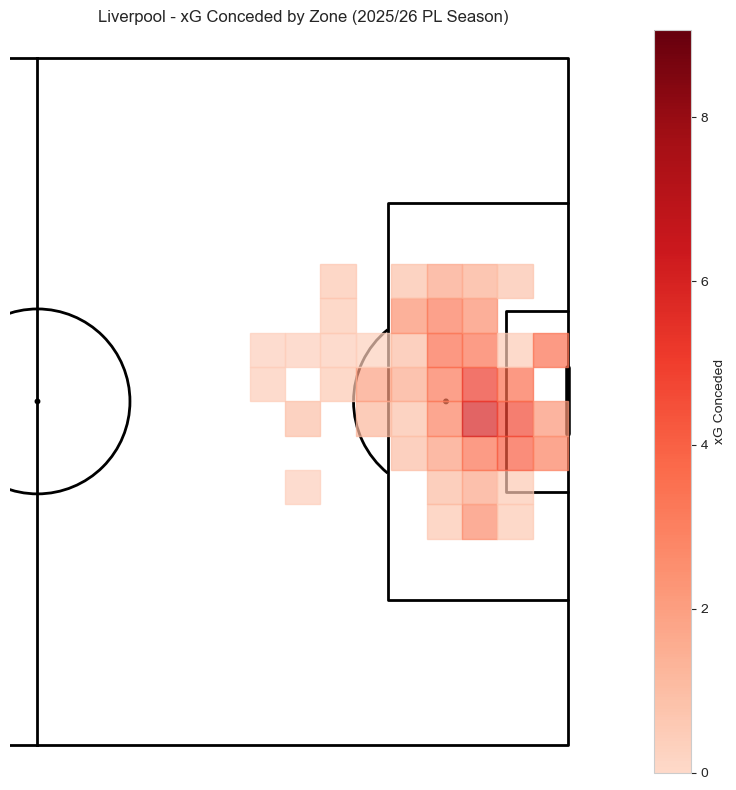

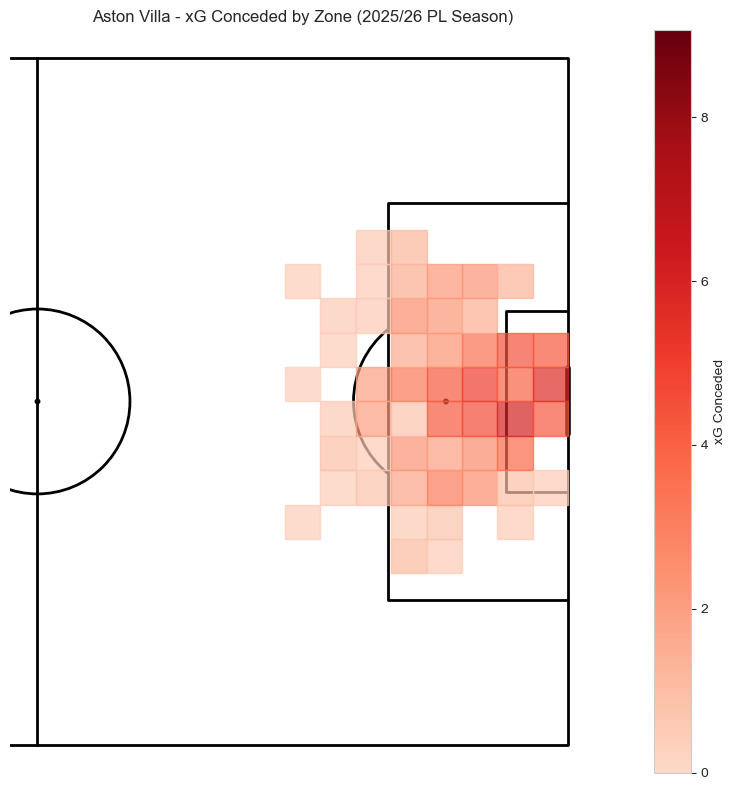

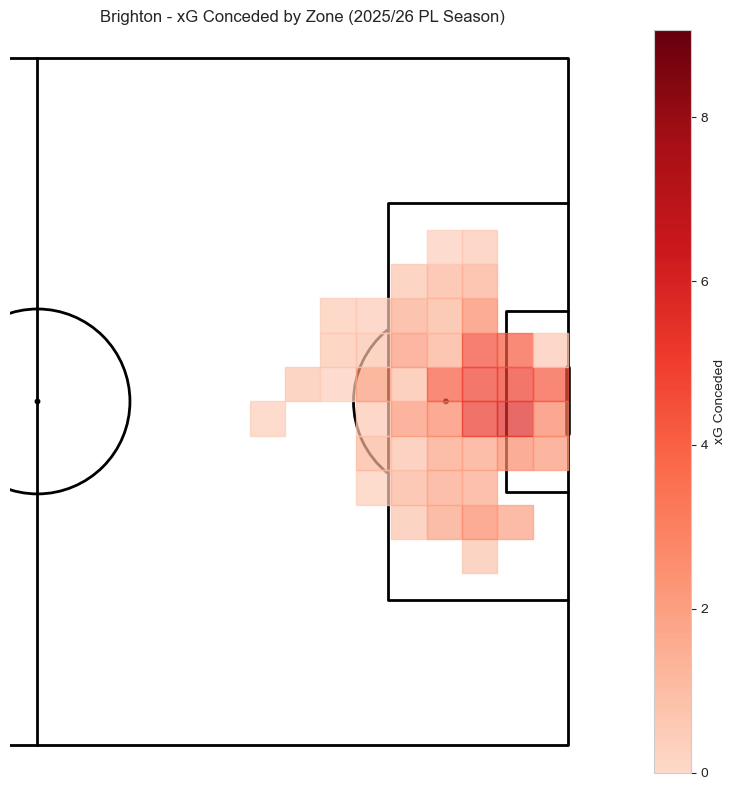

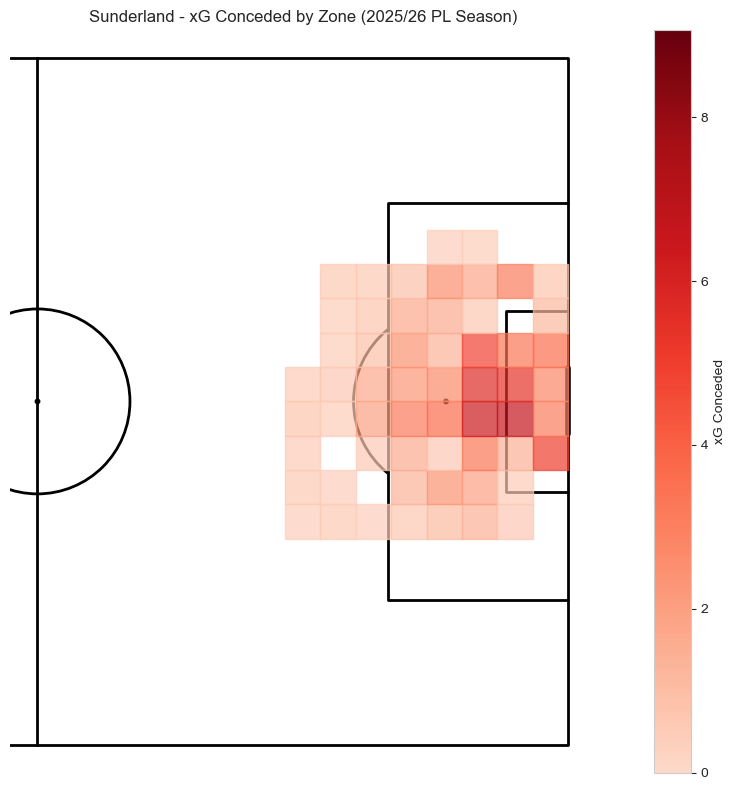

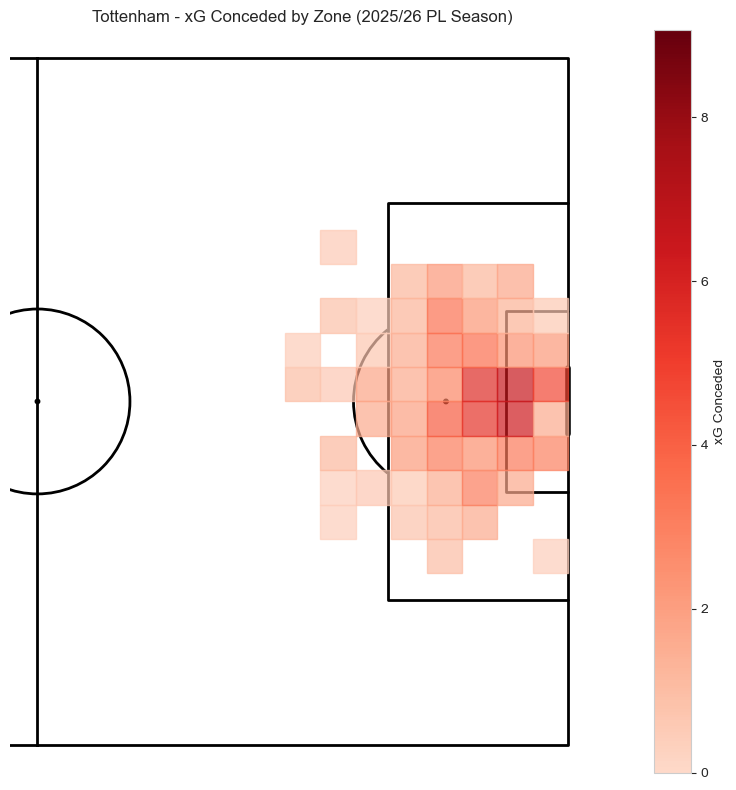

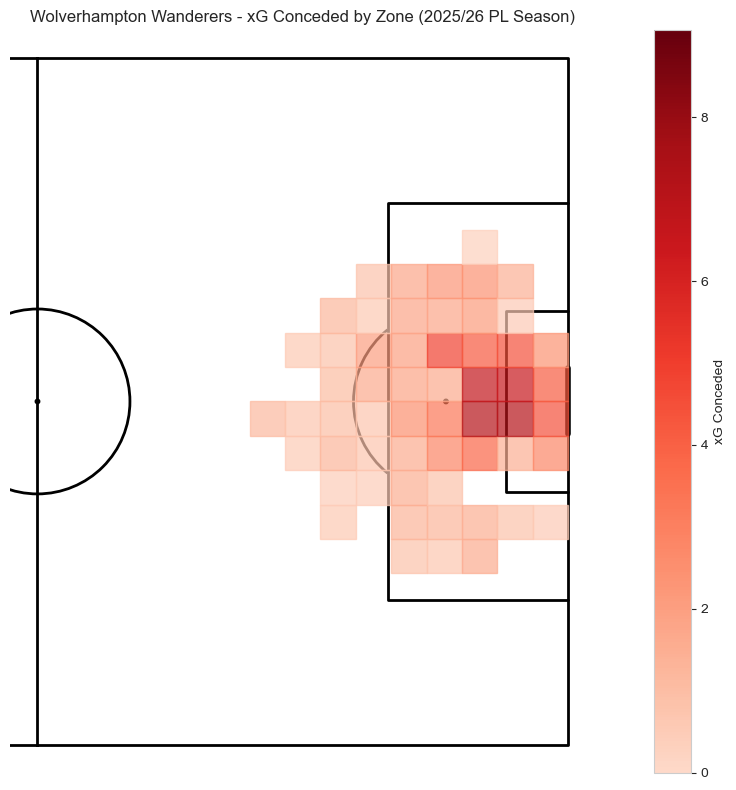

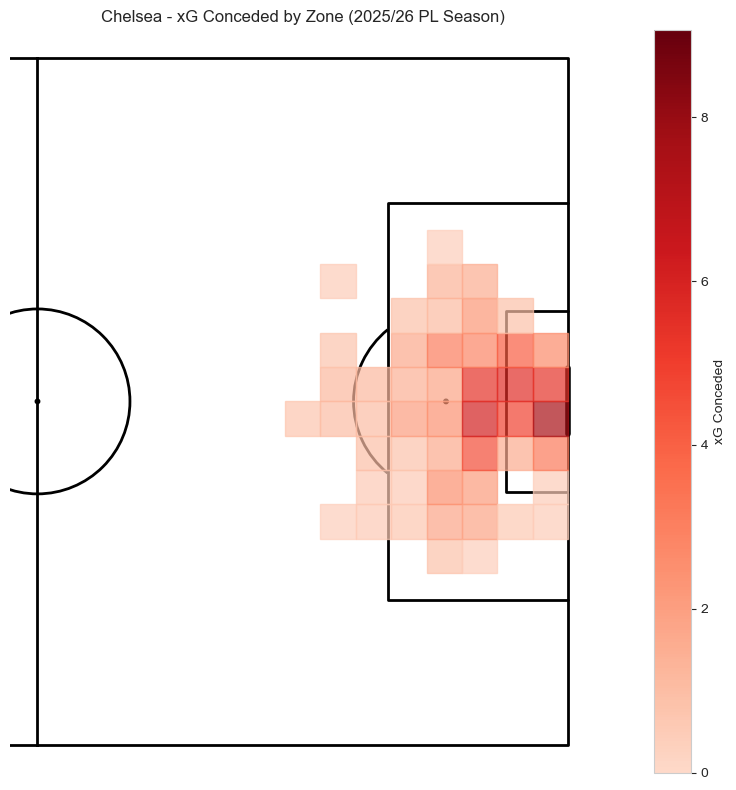

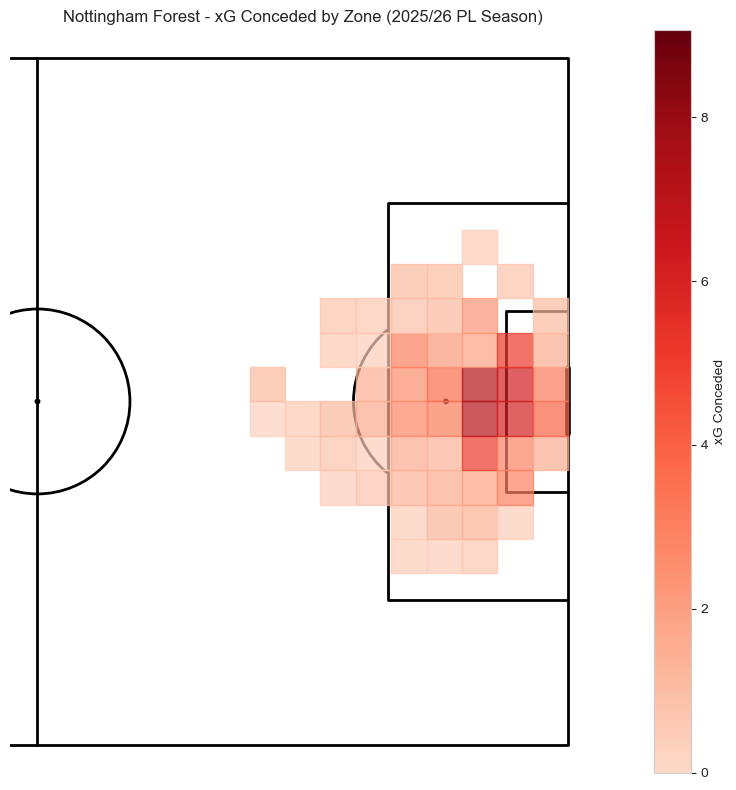

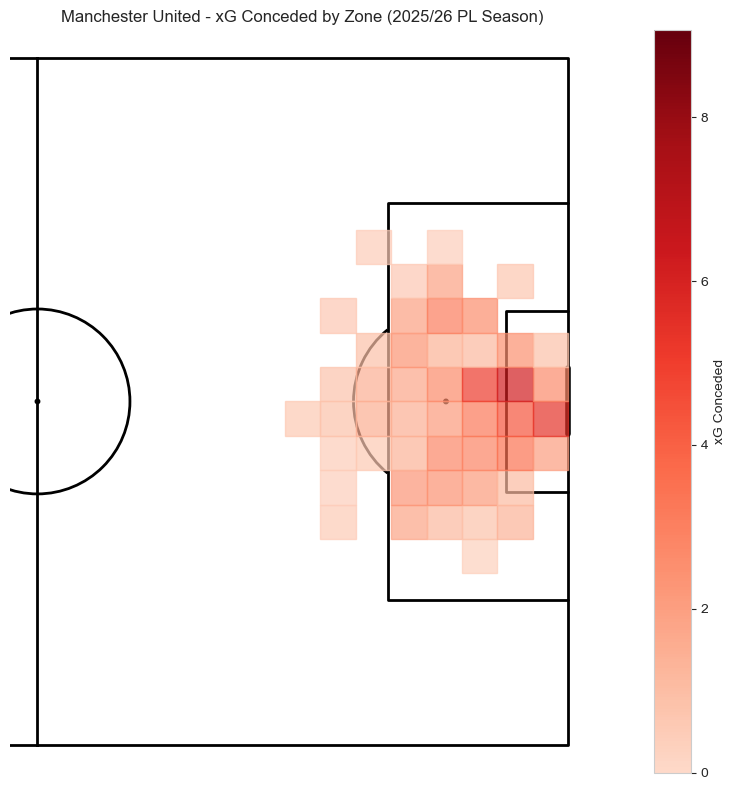

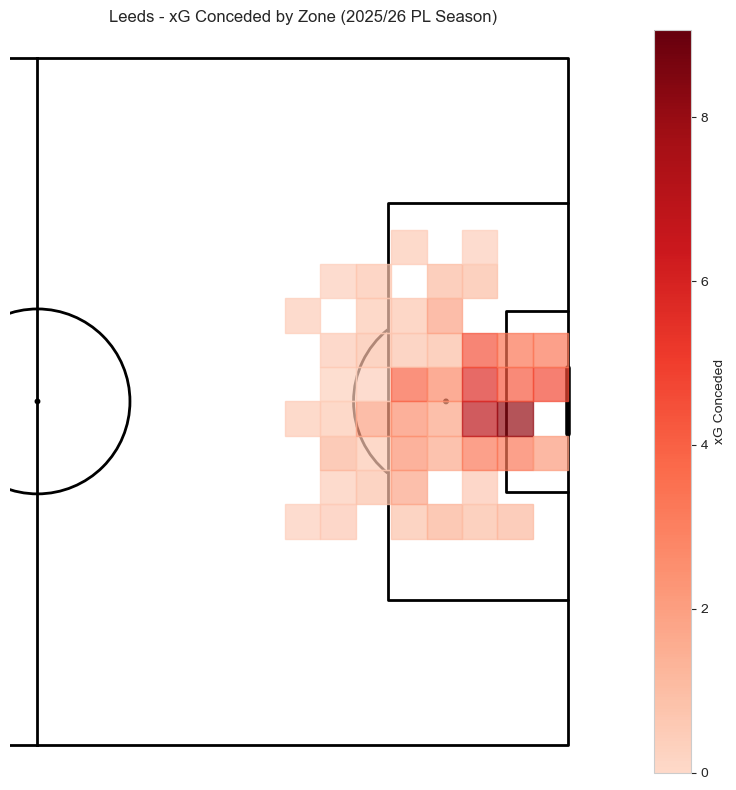

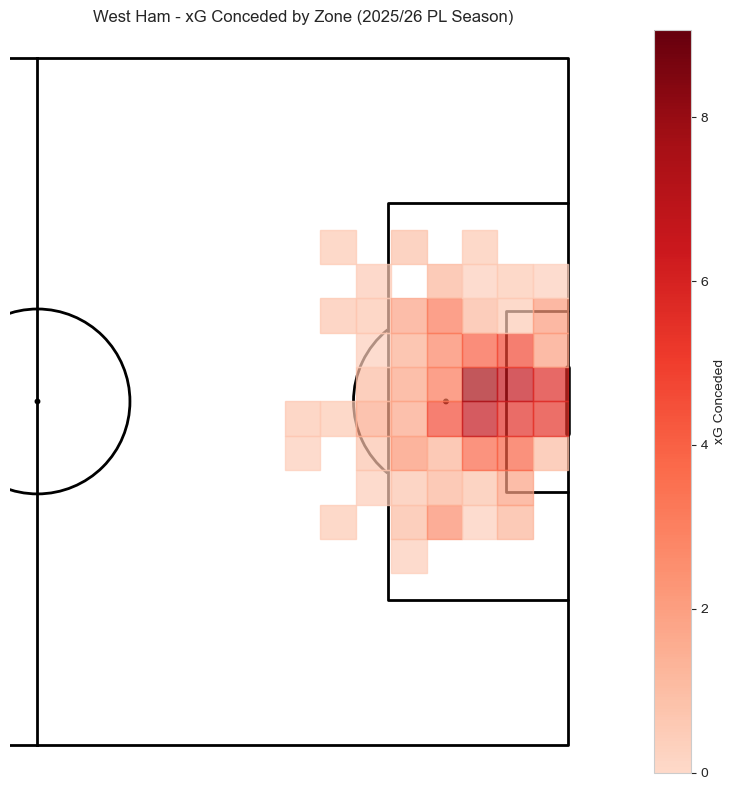

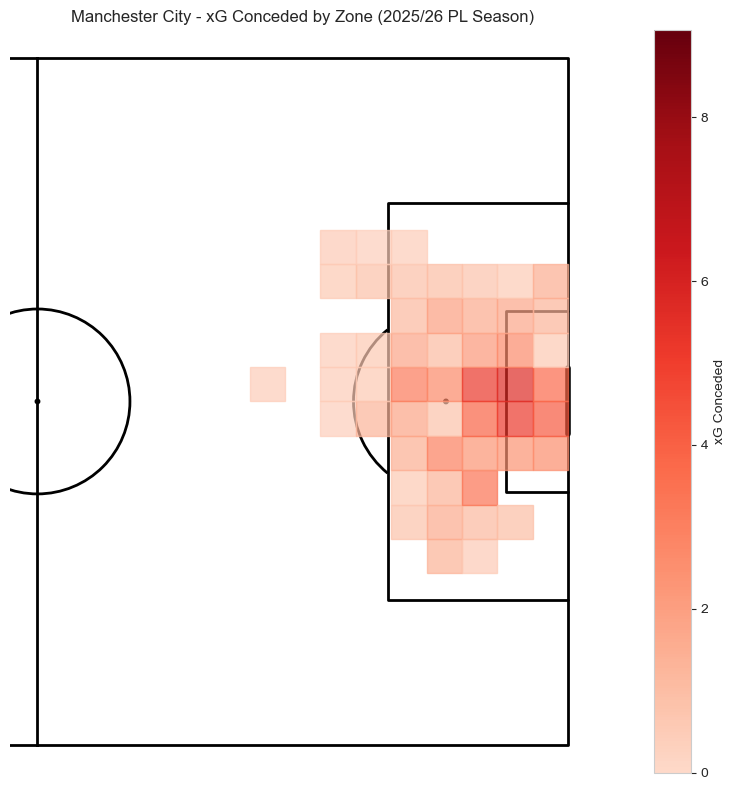

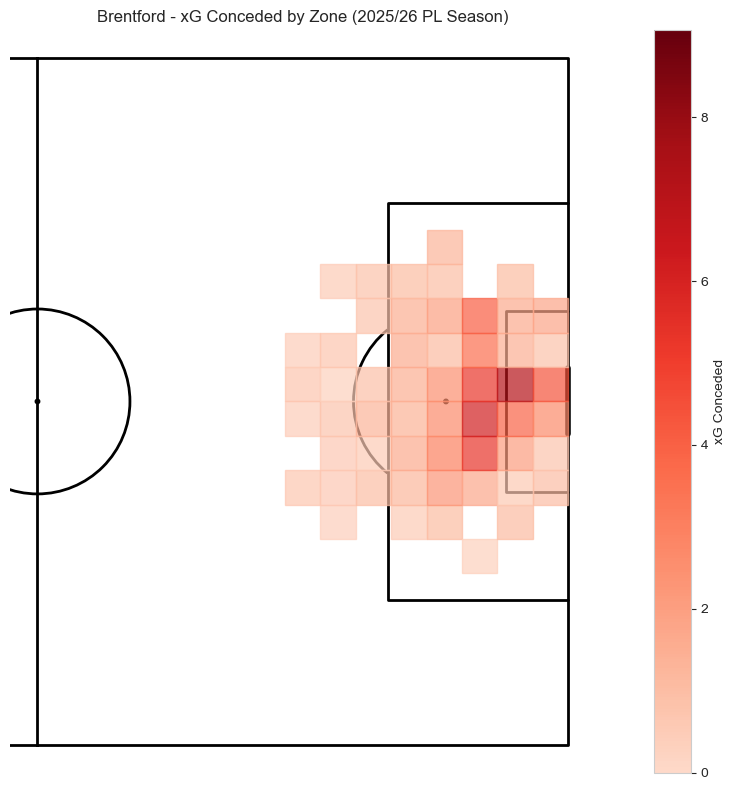

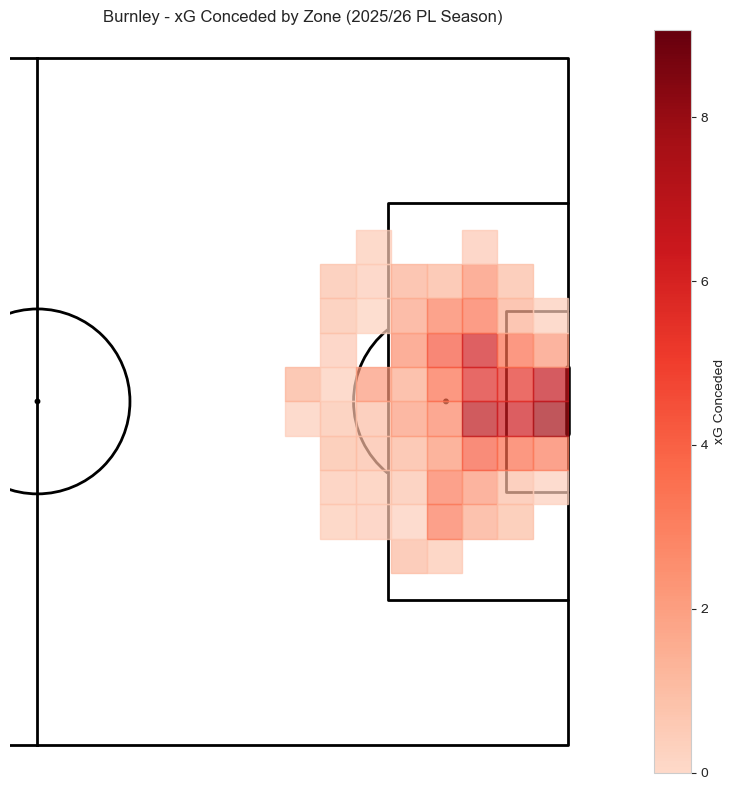

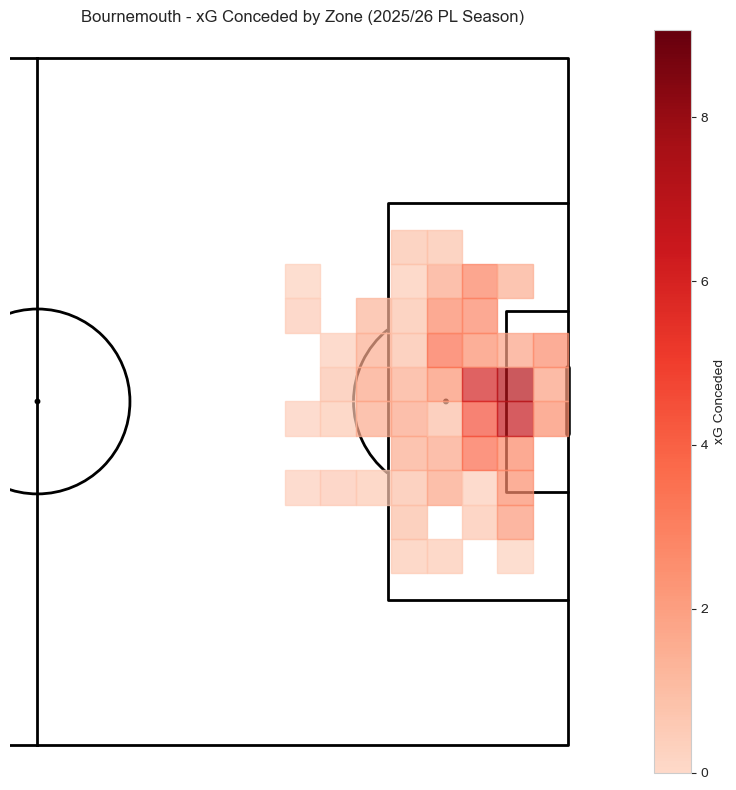

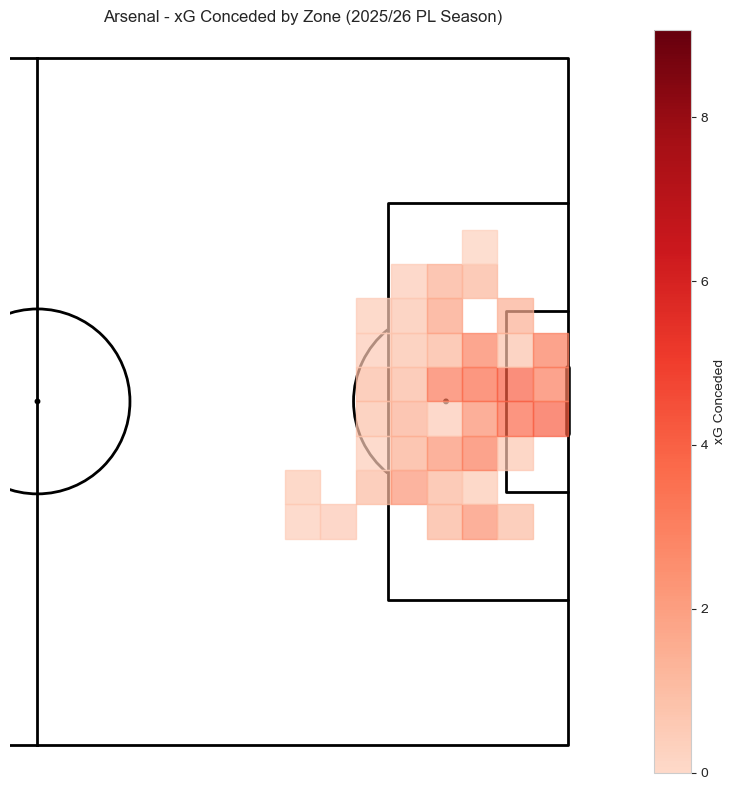

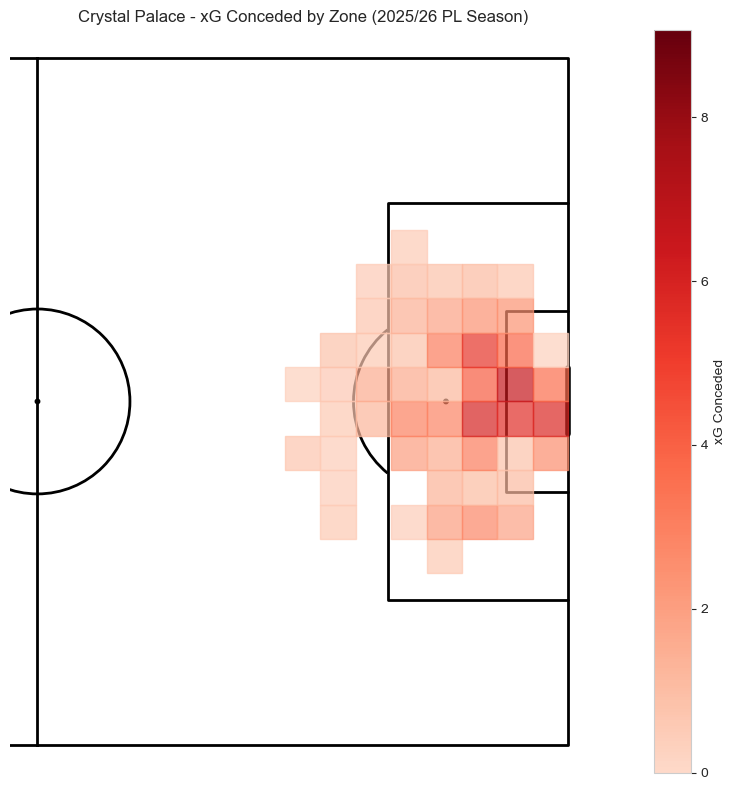

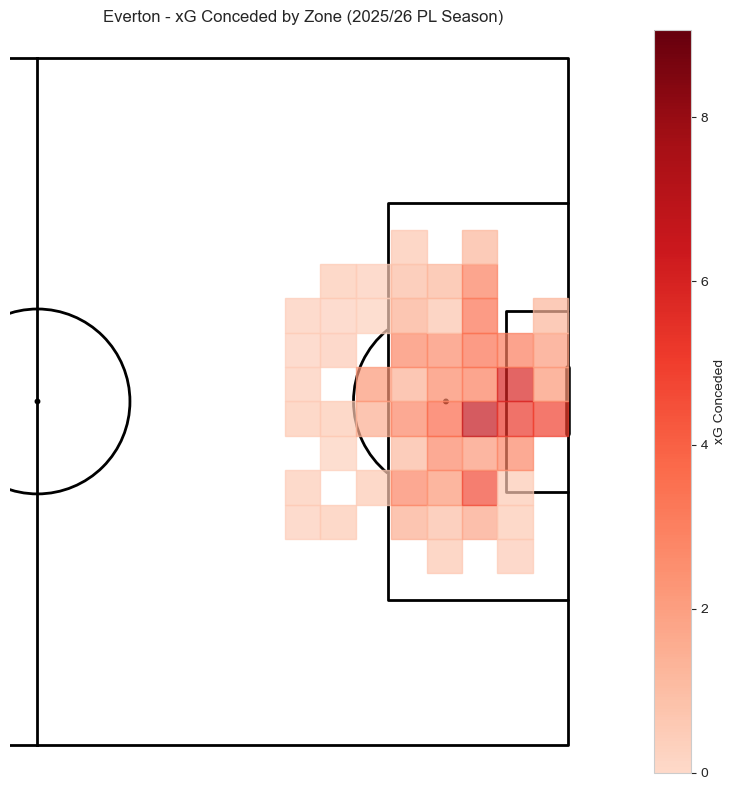

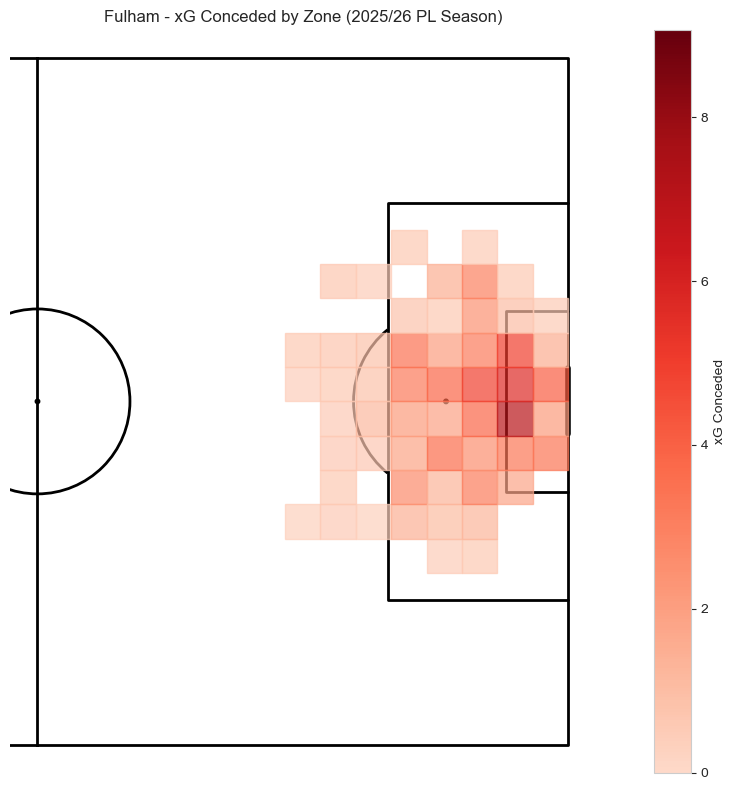

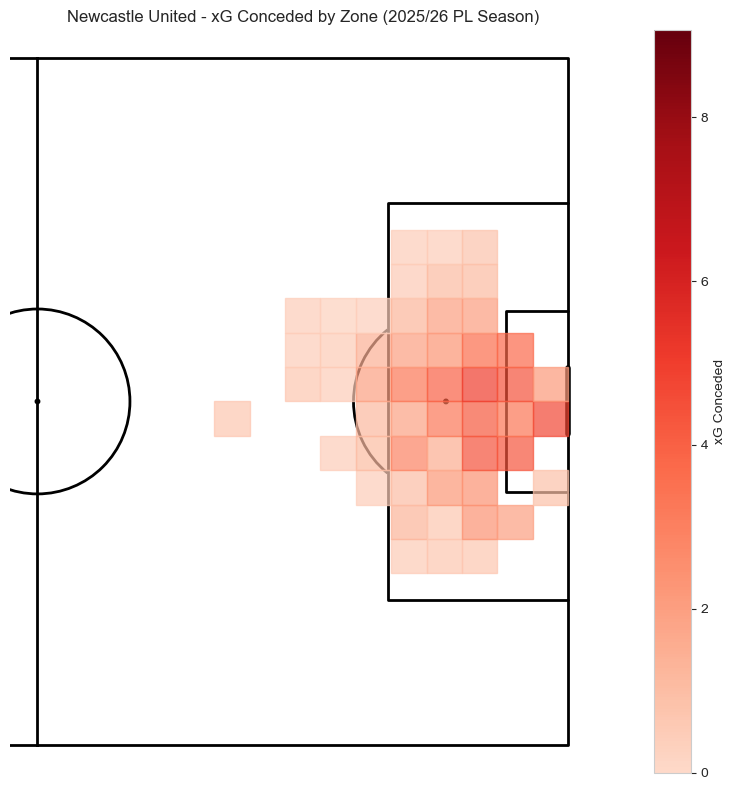

In [62]:
reds_truncated = LinearSegmentedColormap.from_list(
    'reds_truncated', plt.cm.Reds(np.linspace(0.15, 1, 256))
)

teams = noPenShotsdf['h_team'].unique()
global_max = 0

# Finds the maximum across all teams so that teams that the map doesn't appear such that teams with
# better defenses concede as much XG as teams with worst defenses
for team in teams:
    team_conceded = noPenShotsdf[
        ((noPenShotsdf['a_team'] == team) & (noPenShotsdf['h_a'] == 'h')) |
        ((noPenShotsdf['h_team'] == team) & (noPenShotsdf['h_a'] == 'a'))
    ].copy()
    x = team_conceded["X"].astype(float) * 100
    y = team_conceded["Y"].astype(float) * 100
    xg = team_conceded["xG"].astype(float)
    xg_grid, _, _ = np.histogram2d(x, y, bins=[np.linspace(0, 100, 25), np.linspace(0, 100, 17)], weights=xg)
    global_max = max(global_max, xg_grid.max())

for team in teams:
    # Finds if the team we're looking for is the away team and conceding against the home team or vice versa
    team_conceded = noPenShotsdf[
        ((noPenShotsdf['a_team'] == team) & (noPenShotsdf['h_a'] == 'h')) |
        ((noPenShotsdf['h_team'] == team) & (noPenShotsdf['h_a'] == 'a'))
    ].copy()
    x = team_conceded["X"].astype(float) * 100
    y = team_conceded["Y"].astype(float) * 100
    xg = team_conceded["xG"].astype(float)
    x_bins = 30
    y_bins = 20
    x_edges = np.linspace(0, 100, x_bins + 1)
    y_edges = np.linspace(0, 100, y_bins + 1)
    xg_grid, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], weights=xg)
    pitch = Pitch(pitch_type='opta', pitch_color='white', line_color='black', half=True)
    fig, ax = pitch.draw(figsize=(12, 8))
    for i in range(x_bins):
        for j in range(y_bins):
            val = xg_grid[i, j]
            # Zones with less than 0.1 XG mean the team concedes less than 0.0033 expected goals from
            # that zone per game. This data is irrelevant and doesn't need to be seen in the heatmap
            if val < 0.1:
                continue
            intensity = np.log1p(val) / np.log1p(global_max) if global_max > 0 else 0
            color = reds_truncated(intensity) if intensity > 0 else (1, 1, 1, 1)
            rect = plt.Rectangle(
                (x_edges[i], y_edges[j]),
                x_edges[i+1] - x_edges[i],
                y_edges[j+1] - y_edges[j],
                color=color,
                alpha=0.7,
                zorder=2
            )
            ax.add_patch(rect)
    sm = plt.cm.ScalarMappable(cmap=reds_truncated, norm=plt.Normalize(0, global_max))
    plt.colorbar(sm, ax=ax, label='xG Conceded')
    plt.title(f"{team} - xG Conceded by Zone (2025/26 PL Season)")
    plt.show()

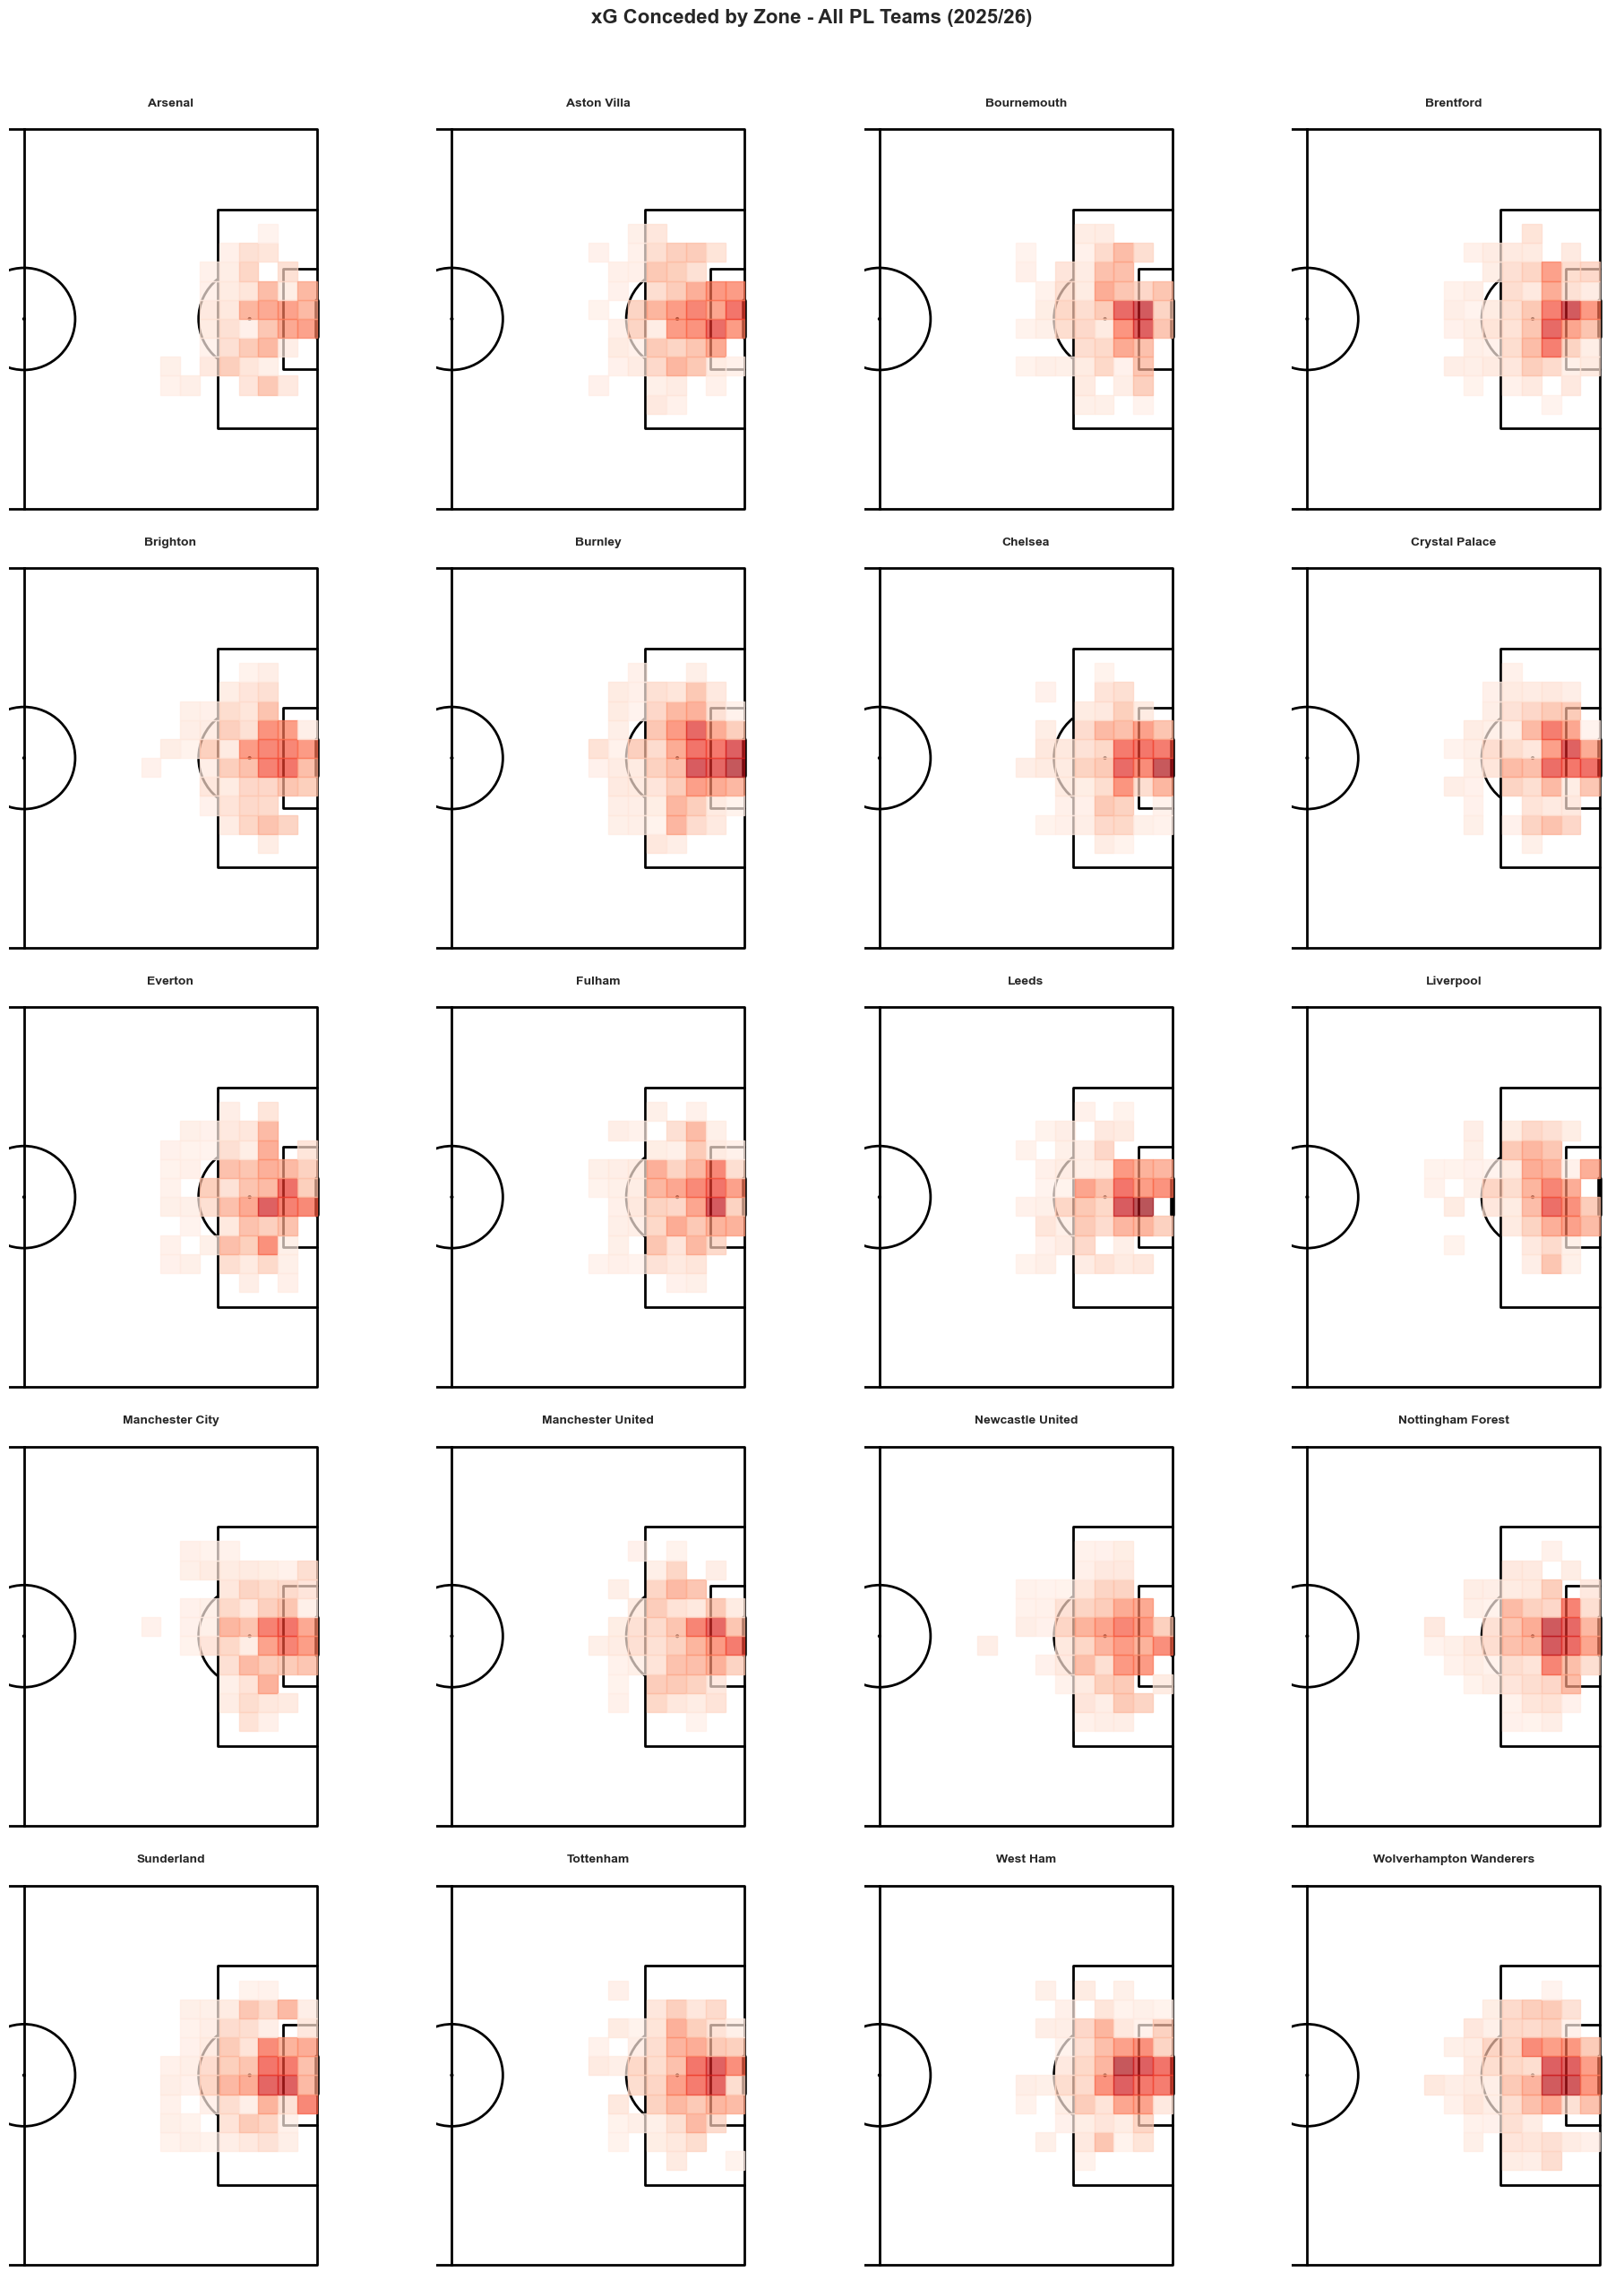

In [63]:
# Create 5X4 group plot of the above histograms
n_teams = len(teams)
n_rows = 5
n_cols = math.ceil(n_teams / n_rows)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, 25))
axes = axes.flatten()

for idx, team in enumerate(sorted(teams)):
    ax = axes[idx]
    team_conceded = noPenShotsdf[
        ((noPenShotsdf['a_team'] == team) & (noPenShotsdf['h_a'] == 'h')) |
        ((noPenShotsdf['h_team'] == team) & (noPenShotsdf['h_a'] == 'a'))
    ].copy()
    x = team_conceded["X"].astype(float) * 100
    y = team_conceded["Y"].astype(float) * 100
    xg = team_conceded["xG"].astype(float)
    x_bins, y_bins = 30, 20
    x_edges = np.linspace(0, 100, x_bins + 1)
    y_edges = np.linspace(0, 100, y_bins + 1)
    xg_grid, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], weights=xg)
    pitch = Pitch(pitch_type='opta', pitch_color='white', line_color='black', half=True)
    pitch.draw(ax=ax)
    for i in range(x_bins):
        for j in range(y_bins):
            val = xg_grid[i, j]
            if val < 0.1:
                continue
            intensity = min(np.log1p(val) / np.log1p(global_max), 1)
            color = plt.cm.Reds(intensity)
            rect = plt.Rectangle(
                (x_edges[i], y_edges[j]),
                x_edges[i+1] - x_edges[i],
                y_edges[j+1] - y_edges[j],
                color=color, alpha=0.7, zorder=2
            )
            ax.add_patch(rect)
    ax.set_title(team, fontsize=10, fontweight='bold')
for idx in range(n_teams, len(axes)):
    axes[idx].set_visible(False)
plt.suptitle("xG Conceded by Zone - All PL Teams (2025/26)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [64]:
# Printed this to manually assign player positions to each player for the positional graph below
print(noPenShotsdf['player'].unique())

['Hugo Ekitike' 'Mohamed Salah' 'Virgil van Dijk' 'Cody Gakpo'
 'Alexis Mac Allister' 'Jeremie Frimpong' 'Dominik Szoboszlai'
 'Florian Wirtz' 'Federico Chiesa' 'Antoine Semenyo' 'Evanilson'
 'Marcus Tavernier' 'David Brooks' 'Boubacar Kamara' 'Ollie Watkins'
 'Donyell Malen' 'Anthony Elanga' 'Anthony Gordon' 'Fabian Schär'
 'Harvey Barnes' 'William Osula' 'Carlos Baleba' 'Georginio Rutter'
 'Kaoru Mitoma' 'Mats Wieffer' 'Yankuba Minteh' 'Diego Gómez' 'Lewis Dunk'
 'Brajan Gruda' 'Raúl Jiménez' 'Harry Wilson' 'Joshua King' 'Alex Iwobi'
 'Emile Smith-Rowe' 'Rodrigo Muniz' 'Habib Diarra' 'Dan Ballard'
 'Eliezer Mayenda' 'Simon Adingra' 'Wilson Isidor' 'Jarrod Bowen'
 'El Hadji Malick Diouf' 'Niclas Füllkrug' 'Guido Rodríguez'
 'Tomas Soucek' 'Callum Wilson' 'Lucas Bergvall' 'Brennan Johnson'
 'Richarlison' 'Djed Spence' 'Micky van de Ven' 'Mohammed Kudus'
 'Pedro Porro' 'Dominic Solanke' 'Jaidon Anthony' 'Oliver Sonne'
 'Josh Laurent' 'Kyle Walker' 'Lyle Foster' 'Maxime Estève'
 'Hanniba

In [65]:
# Manually assigning player positions
player_positions = {
    'Nick Pope': 'GK',
    'Bart Verbruggen': 'GK',
    'Bernd Leno': 'GK',
    'Sam Johnstone': 'GK',
    'Djordje Petrovic': 'GK',
    'Karl Darlow': 'GK',

    'Virgil van Dijk': 'CB',
    'Fabian Schär': 'CB',
    'Lewis Dunk': 'CB',
    'Dan Ballard': 'CB',
    'Maxime Estève': 'CB',
    'Emmanuel Agbadou': 'CB',
    'Maxence Lacroix': 'CB',
    'Nathan Collins': 'CB',
    'Sepp van den Berg': 'CB',
    'Matthijs de Ligt': 'CB',
    'Riccardo Calafiori': 'LB',
    'William Saliba': 'CB',
    'Gabriel': 'CB',
    'Joachim Andersen': 'CB',
    'Cristian Romero': 'CB',
    'Rúben Dias': 'CB',
    'Micky van de Ven': 'CB',
    'Max Kilman': 'CB',
    'Pau Torres': 'CB',
    'Tyrone Mings': 'CB',
    'James Tarkowski': 'CB',
    'Naif Aguerd': 'CB',
    'Marc Guehi': 'CB',
    'Chris Richards': 'CB',
    'Leny Yoro': 'CB',
    'Joe Rodon': 'CB',
    'Nikola Milenkovic': 'CB',
    'Konstantinos Mavropanos': 'CB',
    'Jean-Clair Todibo': 'CB',
    'Jarrad Branthwaite': 'CB',
    'Lisandro Martínez': 'CB',
    'Ben White': 'RB',
    'Murillo': 'CB',
    'Josko Gvardiol': 'CB',
    'Wesley Fofana': 'CB',
    'Tosin Adarabioyo': 'CB',
    'Ethan Pinnock': 'CB',
    'Kevin Danso': 'CB',
    'Santiago Bueno': 'CB',
    'Sven Botman': 'CB',
    'Harry Maguire': 'CB',
    'Victor Lindelöf': 'CB',
    'Ezri Konsa Ngoyo': 'CB',
    'Pascal Struijk': 'CB',
    'Dan Burn': 'CB',
    'Jamaal Lascelles': 'CB',
    'Morato': 'CB',
    'Jorge Cuenca': 'CB',
    'Chadi Riad': 'CB',
    'Omar Alderete': 'CB',
    'Issa Diop': 'CB',
    'Joe Worrall': 'CB',
    'Michael Keane': 'CB',
    'Ben Davies': 'CB',
    'Jaka Bijol': 'CB',
    'Bafode Diakite': 'CB',
    'Noah Sadiki': 'CB',
    'Abduqodir Khusanov': 'CB',
    'Malick Thiaw': 'CB',
    'Yerson Mosquera': 'CB',
    'Jacob Bruun Larsen': 'CB',

    'Jeremie Frimpong': 'RB',
    'Pedro Porro': 'RB',
    'Kyle Walker': 'RB',
    'Trai Hume': 'RB',
    'Djed Spence': 'RB',
    'Reece James': 'RB',
    'Kenny Tete': 'RB',
    'Malo Gusto': 'RB',
    'Diogo Dalot': 'RB',
    'Kyle Walker-Peters': 'RB',
    'Timothy Castagne': 'RB',
    'Nathan Patterson': 'RB',
    'Valentino Livramento': 'RB',
    'Conor Bradley': 'RB',
    'Toti': 'CB',
    'Daniel Muñoz': 'RB',
    'Radu Dragusin': 'CB',
    'Lutsharel Geertruida': 'CB',
    'Nordi Mukiele': 'RB',
    'Quilindschy Hartman': 'LB',
    'Ki-Jana Hoever': 'RB',
    'Matt Doherty': 'RB',
    'Josh Acheampong': 'CB',
    'Michael Kayode': 'RB',
    'Nicolò Savona': 'RB',

    'Andrew Robertson': 'LB',
    'Rayan Ait Nouri': 'LB',
    'Marc Cucurella': 'LB',
    'Antonee Robinson': 'LB',
    'Rico Henry': 'LB',
    'Oleksandr Zinchenko': 'LB',
    'Luke Shaw': 'LB',
    'Ryan Sessegnon': 'LB',
    'Lucas Digne': 'LB',
    'Vitalii Mykolenko': 'LB',
    'Neco Williams': 'LB',
    'Ola Aina': 'RB',
    'Lewis Hall': 'LB',
    'Aaron Hickey': 'LB',
    'Tyrick Mitchell': 'LB',
    'Reinildo': 'LB',
    'Adrien Truffert': 'LB',
    'Milos Kerkez': 'LB',
    'Maxim De Cuyper': 'LB',
    'Dennis Cirkin': 'LB',
    'Rico Lewis': 'LB',
    'Myles Lewis-Skelly': 'LB',
    'Arthur Masuaku': 'LB',
    'Lucas Pires': 'LB',
    'Iyenoma Destiny Udogie': 'LB',
    'Marcos Senesi': 'LB',
    'Hjalmar Ekdal': 'CB',
    'Hugo Bueno': 'LB',
    'Patrick Dorgu': 'LB',

    'Alexis Mac Allister': 'CM',
    'Dominik Szoboszlai': 'AM',
    'Boubacar Kamara': 'CDM',
    'Mats Wieffer': 'RB',
    'Declan Rice': 'CM',
    'Rodri': 'CDM',
    'João Palhinha': 'CDM',
    'Manuel Ugarte': 'CDM',
    'Guido Rodríguez': 'CDM',
    'Tomas Soucek': 'CM',
    'Lucas Bergvall': 'CM',
    'Josh Laurent': 'CM',
    'Hannibal Mejbri': 'CM',
    'Chimuanya Ugochukwu': 'CDM',
    'Jean-Ricner Bellegarde': 'CM',
    'Marshall Munetsi': 'CM',
    'Tijjani Reijnders': 'CM',
    'Moisés Caicedo': 'CDM',
    'Andrey Santos': 'CM',
    'Elliot Anderson': 'CM',
    'Ibrahim Sangare': 'CDM',
    'Yehor Yarmolyuk': 'CM',
    'Mathias Jensen': 'CM',
    'Thiago': 'ST',
    'Bruno Fernandes': 'AM',
    'Martin Odegaard': 'AM',
    'James Ward-Prowse': 'CM',
    'Jordan Henderson': 'CM',
    'Youri Tielemans': 'CM',
    'Amadou Onana': 'CDM',
    'Josh Cullen': 'CDM',
    'Granit Xhaka': 'CDM',
    'Tyler Adams': 'CDM',
    'Martín Zubimendi': 'CDM',
    'Will Hughes': 'CM',
    'Idrissa Gueye': 'CDM',
    'James Garner': 'CM',
    'Carlos Alcaraz': 'AM',
    'Ryan Gravenberch': 'CDM',
    'Bruno Guimarães': 'CM',
    'Joelinton': 'CM',
    'Lewis Miley': 'CM',
    'João Gomes': 'CM',
    'Kiernan Dewsbury-Hall': 'CM',
    'Rodrigo Bentancur': 'CM',
    'Florentino Luís': 'CDM',
    'Christian Nørgaard': 'CDM',
    'Vitaly Janelt': 'CM',
    'Lewis Cook': 'CDM',
    'Casemiro': 'CDM',
    'Kobbie Mainoo': 'CM',
    'Sean Longstaff': 'CM',
    'Wataru Endo': 'CDM',
    'Ethan Ampadu': 'CDM',
    'Douglas Luiz': 'CM',
    'Harrison Reed': 'CDM',
    'Ilia Gruev': 'CDM',
    'Yves Bissouma': 'CDM',
    'Adam Wharton': 'CDM',
    'Sander Berge': 'CDM',
    'Pascal Groß': 'CM',
    'Ryan Yates': 'CM',
    'Sasa Lukic': 'CM',
    'Mikel Merino': 'CM',
    'Joe Willock': 'CM',
    'Jefferson Lerma': 'CDM',
    'Ross Barkley': 'CM',
    'Angel Gomes': 'CM',
    'Tom Cairney': 'CM',
    'Archie Gray': 'CM',
    'Jacob Ramsey': 'LW',
    'Pape Sarr': 'CM',
    'André': 'CDM',
    'Ao Tanaka': 'CM',
    'Anton Stach': 'CM',
    'Lukas Nmecha': 'ST',
    'Freddie Potts': 'CM',
    'Daichi Kamada': 'CM',
    'Ian Maatsen': 'LB',
    'James Justin': 'RB',
    'Jack Hinshelwood': 'CM',
    'Soungoutou Magassa': 'CDM',
    'Mohamadou Kanté': 'CDM',
    'Merlin Röhl': 'CM',
    'Florentino Luís': 'CDM',
    'Oliver Boscagli': 'CDM',

    'Florian Wirtz': 'AM',
    'Federico Chiesa': 'RW',
    'Donyell Malen': 'RW',
    'Anthony Elanga': 'RW',
    'Anthony Gordon': 'LW',
    'Harvey Barnes': 'LW',
    'Georginio Rutter': 'AM',
    'Kaoru Mitoma': 'LW',
    'Yankuba Minteh': 'RW',
    'Brajan Gruda': 'RW',
    'Harry Wilson': 'RW',
    'Alex Iwobi': 'CM',
    'Emile Smith-Rowe': 'AM',
    'Habib Diarra': 'CM',
    'Simon Adingra': 'RW',
    'Jarrod Bowen': 'RW',
    'El Hadji Malick Diouf': 'LB',
    'Mohammed Kudus': 'RW',
    'Jaidon Anthony': 'LW',
    'Oliver Sonne': 'RB',
    'Lyle Foster': 'ST',
    'Mathis Cherki': 'RW',
    'Marc Cucurella': 'LB',
    'Cole Palmer': 'AM',
    'Pedro Neto': 'RW',
    'Jamie Bynoe-Gittens': 'LW',
    'Eberechi Eze': 'AM',
    'Morgan Gibbs-White': 'AM',
    'Dan Ndoye': 'RW',
    'Callum Hudson-Odoi': 'LW',
    'Keane Lewis-Potter': 'LB',
    'Fabio Carvalho': 'AM',
    'Bryan Mbeumo': 'RW',
    'Wilson Odobert': 'LW',
    'Mikkel Damsgaard': 'AM',
    'Dango Ouattara': 'RW',
    'Kevin Schade': 'LW',
    'John McGinn': 'CM',
    'Morgan Rogers': 'AM',
    'Emiliano Buendía': 'AM',
    'Loum Tchaouna': 'RW',
    'Chemsdine Talbi': 'LW',
    'Marc Guiu': 'ST',
    'Patrick Roberts': 'RW',
    'Enzo Le Fée': 'LW',
    'Alex Scott': 'CM',
    'Ryan Christie': 'CM',
    'Justin Kluivert': 'AM',
    'Jhon Arias': 'LW',
    'Ismaila Sarr': 'RW',
    'Justin Devenny': 'AM',
    'Omari Hutchinson': 'RW',
    'Iliman Ndiaye': 'RW',
    'Thierno Barry': 'ST',
    'Tim Iroegbunam': 'CM',
    'Dwight McNeil': 'LW',
    'Yasin Ayari': 'CM',
    'Matt O\'Riley': 'AM',
    'Gabriel Martinelli': 'LW',
    'Bukayo Saka': 'RW',
    'Daniel James': 'LW',
    'Gabriel Gudmundsson': 'LB',
    'Wilfried Gnonto': 'LW',
    'Jayden Bogle': 'RB',
    'Jack Grealish': 'LW',
    'Lucas Paquetá': 'AM',
    'Wilson Isidor': 'ST',
    'Nico González': 'CDM',
    'Joël Piroe': 'ST',
    'Leandro Trossard': 'LW',
    'Ethan Nwaneri': 'AM',
    'Reiss Nelson': 'RW',
    'Brenden Aaronson': 'AM',
    'Xavi Simons': 'AM',
    'Sávio': 'RW',
    'Jéremy Doku': 'LW',
    'Oscar Bobb': 'RW',
    'Noni Madueke': 'RW',
    'Matheus Cunha': 'LW',
    'Amad Diallo Traore': 'RW',
    'Mason Mount': 'AM',
    'Phil Foden': 'AM',
    'Bernardo Silva': 'CM',
    'Kieran Trippier': 'RB',
    'Leon Bailey': 'RW',
    'Facundo Buonanotte': 'AM',
    'Kai Havertz': 'ST',
    'Marcus Edwards': 'RW',
    'Adama Traoré': 'RW',
    'Bertrand Traoré': 'RW',
    'Samuel Chukwueze': 'RW',
    'Crysencio Summerville': 'LW',
    'Mateus Fernandes': 'CM',
    'Alejandro Garnacho': 'LW',
    'Mathys Tel': 'RW',
    'Hee-Chan Hwang': 'LW',
    'Rodrigo Gomes': 'RB',
    'Noah Okafor': 'LW',
    'Harvey Elliott': 'AM',
    'Jadon Sancho': 'LW',
    'Curtis Jones': 'CM',
    'Ben Doak': 'RW',
    'Matheus Nunes': 'RB',
    'James McAtee': 'AM',
    'Conor Gallagher': 'CM',
    'Romaine Mundle': 'LW',
    'Tom Watson': 'RW',
    'Luis Guilherme': 'LW',
    'Tyrique George': 'LW',
    'Rio Ngumoha': 'LW',
    'Nilson Angulo': 'LW',
    'Tom Edozie': 'LW',
    'Dilane Bakwa': 'RB',
    'Jack Harrison': 'LW',
    'Nick Woltemade': 'AM',
    'Amine Adli': 'LW',
    'Yeremi Pino': 'LW',
    'Evann Guessand': 'RW',
    'Callum Marshall': 'LW',
    'Charalampos Kostoulas': 'ST',
    'Rayan': 'RW',
    'Alejandro Jiménez': 'RB',
    'Chris Rigg': 'AM',
    'Eli Junior Kroupi': 'LW',
    'Stefanos Tzimas': 'AM',
    'Yoane Wissa': 'ST',
    'Tyler Dibling': 'AM',
    'Bashir Humphreys': 'CB',
    'Oliver Scarles': 'LB',
    'Joël Veltman': 'RB',
    'Trevoh Chalobah': 'CB',
    'Ibrahima Konaté': 'CB',
    'Kristoffer Ajer': 'CB',
    'Joseph Gomez': 'CB',
    'Nathaniel Clyne': 'RB',
    'Noussair Mazraoui': 'RB',
    'Jacob Murphy': 'RW',
    'Kevin': 'LW',
    'Piero Hincapié': 'LB',
    'Mamadou Sarr': 'CB',
    'Pablo': 'AM',
    'Jorrel Hato': 'LB',
    'Axel Tuanzebe': 'CB',
    'Axel Disasi': 'CB',
    'Ladislav Krejcí': 'CB',
    'Jean-Clair Todibo': 'CB',
    'Alysson Edward': 'LW',
    'Max Alleyne': 'CB',
    'Romelle Donovan': 'RW',
    'George Hemmings': 'CM',
    'Ayden Heaven': 'CB',
    'Max Dowman': 'RW',
    'Shea Lacey': 'ST',
    'Ezra Mayers': 'LW',
    'Jack Fletcher': 'CM',
    'Harrison Armstrong': 'AM',
    'Treymaurice Nyoni': 'CB',
    'Jair': 'RW',
    'Souza': 'CDM',

    'Hugo Ekitike': 'ST',
    'Mohamed Salah': 'RW',
    'Antoine Semenyo': 'RW',
    'Evanilson': 'ST',
    'Marcus Tavernier': 'AM',
    'David Brooks': 'RW',
    'Ollie Watkins': 'ST',
    'William Osula': 'ST',
    'Carlos Baleba': 'CDM',
    'Diego Gómez': 'RW',
    'Raúl Jiménez': 'ST',
    'Joshua King': 'AM',
    'Rodrigo Muniz': 'ST',
    'Eliezer Mayenda': 'ST',
    'Niclas Füllkrug': 'ST',
    'Callum Wilson': 'ST',
    'Dominic Solanke': 'ST',
    'Jørgen Strand Larsen': 'ST',
    'Erling Haaland': 'ST',
    'Omar Marmoush': 'ST',
    'Liam Delap': 'ST',
    'Jean-Philippe Mateta': 'ST',
    'Chris Wood': 'ST',
    'Viktor Gyokeres': 'ST',
    'Richarlison': 'ST',
    'Brennan Johnson': 'RW',
    'Dominic Calvert-Lewin': 'ST',
    'Benjamin Sesko': 'ST',
    'Alexander Isak': 'ST',
    'Tammy Abraham': 'ST',
    'Lorenzo Lucca': 'ST',
    'Randal Kolo Muani': 'ST',
    'Brian Brobbey': 'ST',
    'Armando Broja': 'ST',
    'Enes Ünal': 'ST',
    'Tolu Arokodare': 'ST',
    'Eddie Nketiah': 'ST',
    'Adam Armstrong': 'ST',
    'Beto': 'ST',
    'Gabriel Jesus': 'ST',
    'Taiwo Awoniyi': 'ST',
    'Valentín Castellanos': 'ST',
    'Danny Welbeck': 'ST',
    'Ashley Barnes': 'ST',
    'Christantus Uche': 'ST',
    'Arnaud Kalimuendo Muinga': 'ST',
    'Joshua Zirkzee': 'ST',
    'James Hill': 'CB',
    'Jackson Tchatchoua': 'RB',
    'Mateus Mané': 'AM',
    'Veljko Milosavljevic': 'ST',
    'Jan Paul van Hecke': 'CB',
    'Calvin Bassey': 'CB',
    'Nathan Aké': 'CB',
    'Jaydee Canvot': 'CB',
    'David Møller Wolfe': 'LB',
    'Nicolás Domínguez': 'CM',
    'Leny Yoro': 'CB',
    'Cody Gakpo': 'LW',
    'Fernando López': 'ST',
    'João Pedro': 'ST',
    'Estêvão': 'RW',
    'Jake O&#039;Brien': 'CB',
    'Enzo Fernández': 'CM',
    'Jurriën Timber': 'RB',
    'Igor Jesus': 'ST',
    'Matt O&#039;Riley': 'AM',
    'Sandro Tonali': 'CDM',
    'Nico O&#039;Reilly': 'LB',
    'Matthew Cash': 'RB',
    'Ferdi Kadioglu': 'LB',
    'Zian Flemming': 'ST',
    'James Milner': 'CM',
    'Olivier Boscagli': 'CB',
    'Alex Tóth': 'AM',
}

In [66]:
noPenShotsdf['position'] = noPenShotsdf['player'].map(player_positions)
position_order = ['CB', 'RB', 'LB', 'CDM', 'CM', 'AM', 'RW', 'LW', 'ST']

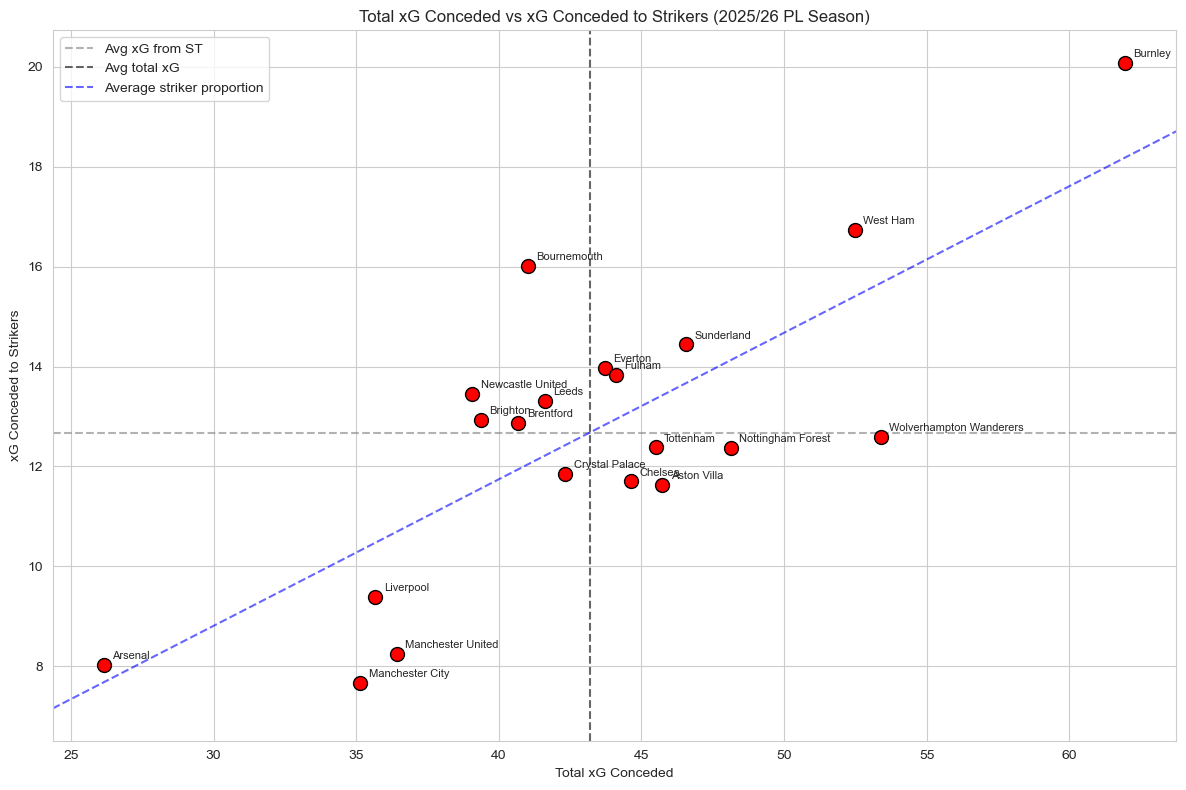

In [67]:
scatter_data = []

for team in teams:
    team_conceded = noPenShotsdf[
        ((noPenShotsdf['a_team'] == team) & (noPenShotsdf['h_a'] == 'h')) |
        ((noPenShotsdf['h_team'] == team) & (noPenShotsdf['h_a'] == 'a'))
    ].copy()
    team_conceded = team_conceded.dropna(subset=['position'])
    team_conceded = team_conceded[team_conceded['position'] != 'GK']

    total_xg = team_conceded['xG'].sum()
    st_xg = team_conceded[team_conceded['position'] == 'ST']['xG'].sum()

    scatter_data.append({'team': team, 'total_xg': total_xg, 'st_xg': st_xg})

scatter_df = pd.DataFrame(scatter_data)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(scatter_df['total_xg'], scatter_df['st_xg'], color='red', edgecolors='black', s=100, zorder=3)

for _, row in scatter_df.iterrows():
    ax.annotate(row['team'], (row['total_xg'], row['st_xg']),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.axhline(scatter_df['st_xg'].mean(), color='gray', linestyle='--', alpha=0.6, label='Avg xG from ST')
ax.axvline(scatter_df['total_xg'].mean(), color='black', linestyle='--', alpha=0.6, label='Avg total xG')
ax.set_xlabel('Total xG Conceded')
ax.set_ylabel('xG Conceded to Strikers')
ax.set_title('Total xG Conceded vs xG Conceded to Strikers (2025/26 PL Season)')
ax.legend()
x1, y1 = 0, 0
x2, y2 = scatter_df['total_xg'].mean(), scatter_df['st_xg'].mean()

slope = (y2 - y1) / (x2 - x1)

x_min, x_max = ax.get_xlim()
x_line = np.linspace(x_min, x_max, 100)
y_line = slope * x_line

ax.plot(x_line, y_line, color='blue', linestyle='--', alpha=0.6, label='Average striker proportion')
ax.set_xlim(x_min, x_max)
ax.legend()
plt.tight_layout()
plt.show()

In [68]:
shotsdf = shotsdf[shotsdf['season'] == 2025]

In [69]:
# Global Preprocessing
shotsdf['X'] = shotsdf['X'].astype(float)
shotsdf['Y'] = shotsdf['Y'].astype(float)
shotsdf['team'] = np.where(shotsdf['h_a'] == 'h', shotsdf['h_team'], shotsdf['a_team'])

# Global Player Aggregation (used across multiple plots)
df_player = shotsdf.groupby(['player', 'team']).agg({
    'xG': 'sum',
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

df_player.columns = ['player', 'team', 'total_xG', 'actual_goals']
df_player['xg_delta'] = df_player['actual_goals'] - df_player['total_xG']

player_stats = shotsdf.groupby('player').agg({
    'xG': ['sum', 'count', 'mean'],
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

player_stats.columns = ['player', 'total_xG', 'shot_count', 'avg_xG_per_shot', 'goals']
top_forwards = player_stats.sort_values(by='total_xG', ascending=False).head(10)

print("Top 10 Players by Total xG (Likely Forwards):")
print(top_forwards)

# Shared Function for Pitch Maps
def plot_player_shots(player_name, df):
    player_df = df[df['player'] == player_name]
    pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')
    fig, ax = pitch.draw(figsize=(10, 7))
    
    goals = player_df[player_df['result'] == 'Goal']
    non_goals = player_df[player_df['result'] != 'Goal']
    
    pitch.scatter(non_goals.X * 100, non_goals.Y * 100, s=100, 
                  edgecolors='white', c='#ea6969', alpha=0.7, ax=ax, label='No Goal')
    pitch.scatter(goals.X * 100, goals.Y * 100, s=200, 
                  edgecolors='black', c='#2fb380', marker='*', ax=ax, label='Goal')
    
    plt.title(f"Shot Map: {player_name} (Total xG: {player_df.xG.sum():.2f})", color='white', size=16)
    plt.legend()
    plt.show()

Top 10 Players by Total xG (Likely Forwards):
                    player   total_xG  shot_count  avg_xG_per_shot  goals
113         Erling Haaland  23.136934         102         0.226833     22
389                 Thiago  21.046960          70         0.300671     19
212             João Pedro  14.059572          61         0.230485     14
95   Dominic Calvert-Lewin  12.980034          56         0.231786     10
189   Jean-Philippe Mateta  12.959903          55         0.235635      8
150           Hugo Ekitike  11.932188          65         0.183572     11
330          Ollie Watkins  11.483466          57         0.201464      8
23         Antoine Semenyo  11.201725          68         0.164731     15
351           Raúl Jiménez  10.750260          61         0.176234      8
111         Enzo Fernández  10.236897          57         0.179595      8


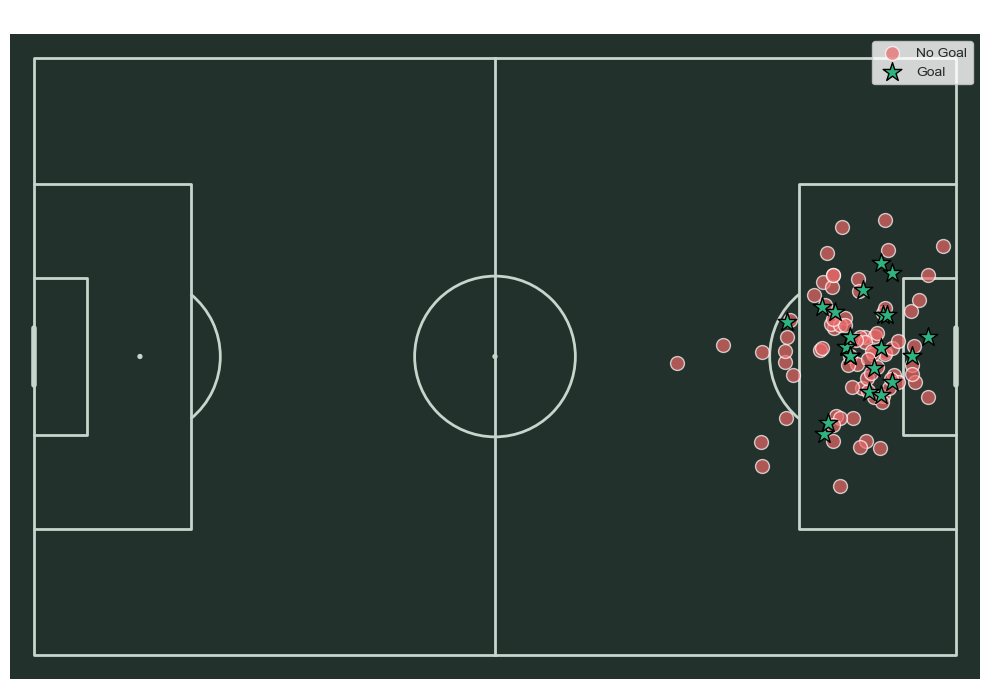

In [70]:
# Visualize the player with the highest xG
top_player = top_forwards.iloc[0]['player']
plot_player_shots(top_player, shotsdf)    

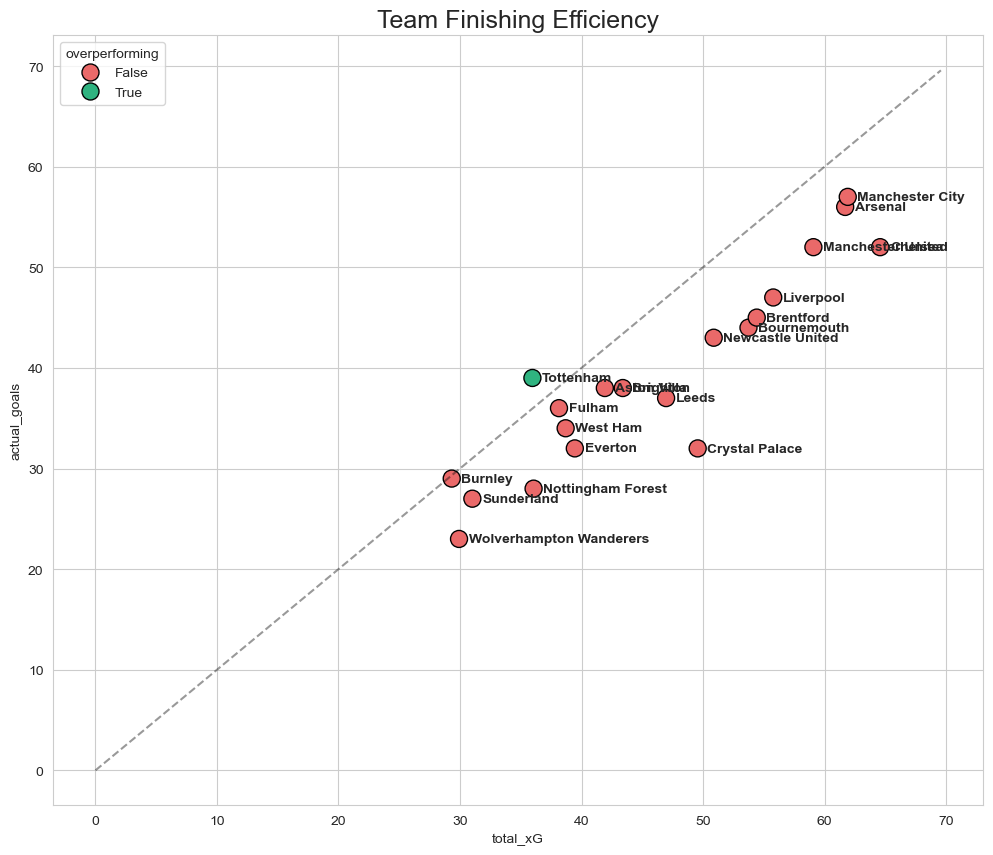

In [71]:
# Aggregate by Team
team_perf = df_player.groupby('team').agg({
    'total_xG': 'sum',
    'actual_goals': 'sum'
}).reset_index()

team_perf['overperforming'] = team_perf['actual_goals'] > team_perf['total_xG']

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")
sns.scatterplot(data=team_perf, x='total_xG', y='actual_goals', hue='overperforming', 
                palette={True: '#2fb380', False: '#ea6969'}, s=150, edgecolor='black')

# 45-degree line
limit = max(team_perf['total_xG'].max(), team_perf['actual_goals'].max()) + 5
plt.plot([0, limit], [0, limit], color='black', linestyle='--', alpha=0.4)

for i, row in team_perf.iterrows():
    plt.annotate(row['team'], (row['total_xG'], row['actual_goals']), xytext=(7, 0), 
                 textcoords='offset points', fontsize=10, va='center', fontweight='bold')

plt.title("Team Finishing Efficiency", fontsize=18)
plt.show()

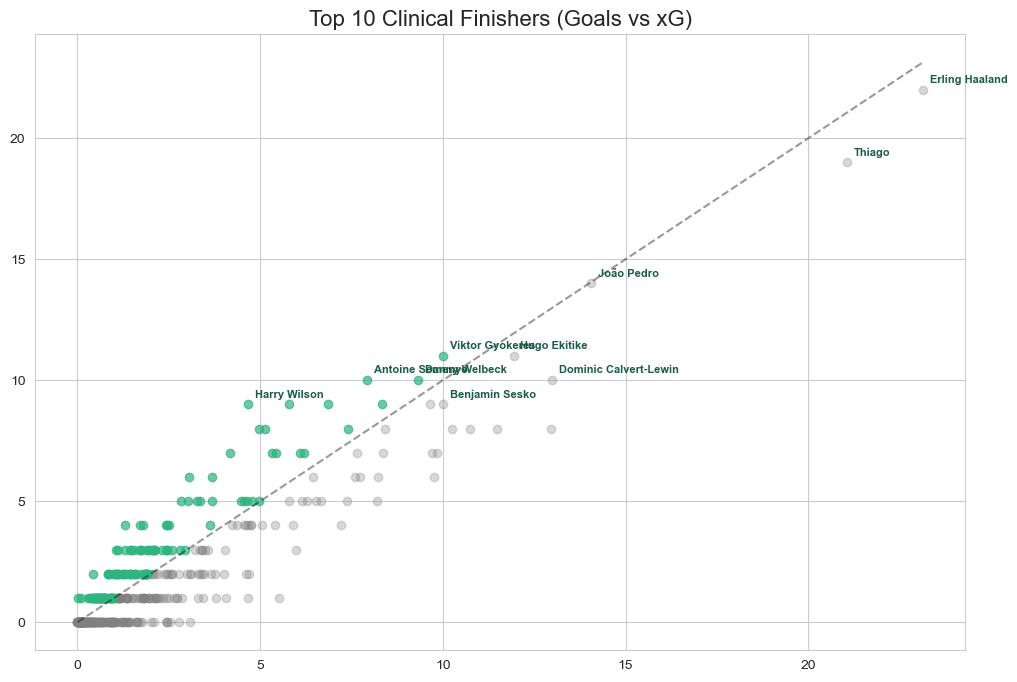

In [72]:
top_finishers = df_player.sort_values(by='actual_goals', ascending=False).head(10)

plt.figure(figsize=(12, 8))
over = df_player[df_player['xg_delta'] > 0]
under = df_player[df_player['xg_delta'] <= 0]

plt.scatter(under['total_xG'], under['actual_goals'], alpha=0.3, color='gray')
plt.scatter(over['total_xG'], over['actual_goals'], alpha=0.7, color='#2fb380')

# Parity line
max_v = df_player[['total_xG', 'actual_goals']].max().max()
plt.plot([0, max_v], [0, max_v], color='black', linestyle='--', alpha=0.4)

for i, row in top_finishers.iterrows():
    plt.annotate(row['player'], (row['total_xG'], row['actual_goals']), xytext=(5, 5), 
                 textcoords='offset points', fontsize=8, fontweight='bold', color='#1a5e45')

plt.title("Top 10 Clinical Finishers (Goals vs xG)", fontsize=16)
plt.show()


Defensive Performance (xG Conceded):
                       team  xG_conceded  shots_faced  goals_conceded
5                   Burnley    66.523170          501              54
18                 West Ham    57.055869          453              53
19  Wolverhampton Wanderers    55.685142          430              50
15        Nottingham Forest    51.946432          378              41
16               Sunderland    48.843244          442              34
1               Aston Villa    47.255291          388              36
9                    Fulham    47.162186          356              40
17                Tottenham    47.026621          390              47
7            Crystal Palace    46.893879          345              34
10                    Leeds    46.177427          366              46
3                 Brentford    46.011357          372              39
8                   Everton    45.993794          411              34
6                   Chelsea    45.391847          32

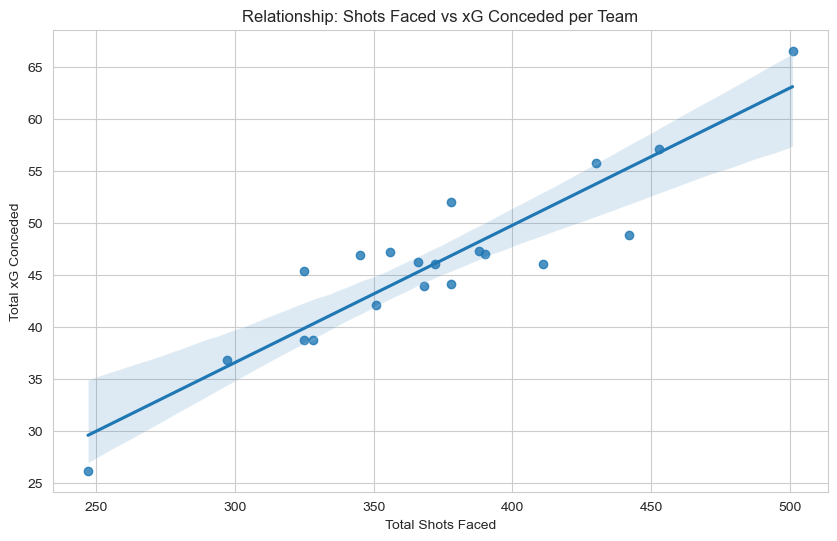


xG Conceded by Situation:
situation       DirectFreekick  FromCorner   OpenPlay   Penalty  SetPiece
defending_team                                                           
Arsenal               0.345943    3.172405  20.076777  0.000000  2.557181
Aston Villa           0.483787    7.971429  34.601158  1.522338  2.676580
Bournemouth           0.579238    8.716299  28.050008  3.044639  3.673775
Brentford             0.377864    4.784751  33.415052  5.328182  2.105508
Brighton              0.434912    5.063713  30.850059  4.567013  3.020842


In [73]:
# ---------------------------------------------------------
# QUESTION 2: Teams/Defenses Conceding xG
# ---------------------------------------------------------

# To find which 'defense' concedes the most, we look at the opponent 
# When h_a == 'h', the shot was taken by the home team, so the away team (a_team) was defending.
shotsdf['defending_team'] = shotsdf.apply(lambda x: x['a_team'] if x['h_a'] == 'h' else x['h_team'], axis=1)

defensive_stats = shotsdf.groupby('defending_team').agg({
    'xG': ['sum', 'count'],
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

defensive_stats.columns = ['team', 'xG_conceded', 'shots_faced', 'goals_conceded']
defensive_stats = defensive_stats.sort_values(by='xG_conceded', ascending=False)

print("\nDefensive Performance (xG Conceded):")
print(defensive_stats)

# Plotting the relationship between shots faced and xG conceded
plt.figure(figsize=(10,6))
sns.regplot(data=defensive_stats, x='shots_faced', y='xG_conceded')
plt.title("Relationship: Shots Faced vs xG Conceded per Team")
plt.xlabel("Total Shots Faced")
plt.ylabel("Total xG Conceded")
plt.show()

# ---------------------------------------------------------
# QUESTION 3: Relationship with Situations (Proxy for Phase)
# ---------------------------------------------------------

# Since we don't have formation data, we analyze 'situation' (OpenPlay, FromCorner, etc.)
# This helps identify if teams concede more during specific phases.
situation_analysis = shotsdf.groupby(['defending_team', 'situation'])['xG'].sum().unstack().fillna(0)
print("\nxG Conceded by Situation:")
print(situation_analysis.head())


Attacking Performance (xG Generated):
                 team  xG_generated  shots_taken  goals_scored  xG_per_shot
6             Chelsea     64.575106          414            52     0.155979
12    Manchester City     61.908537          442            57     0.140065
0             Arsenal     61.696627          455            56     0.135597
13  Manchester United     59.081919          480            52     0.123087
11          Liverpool     55.777086          470            47     0.118675


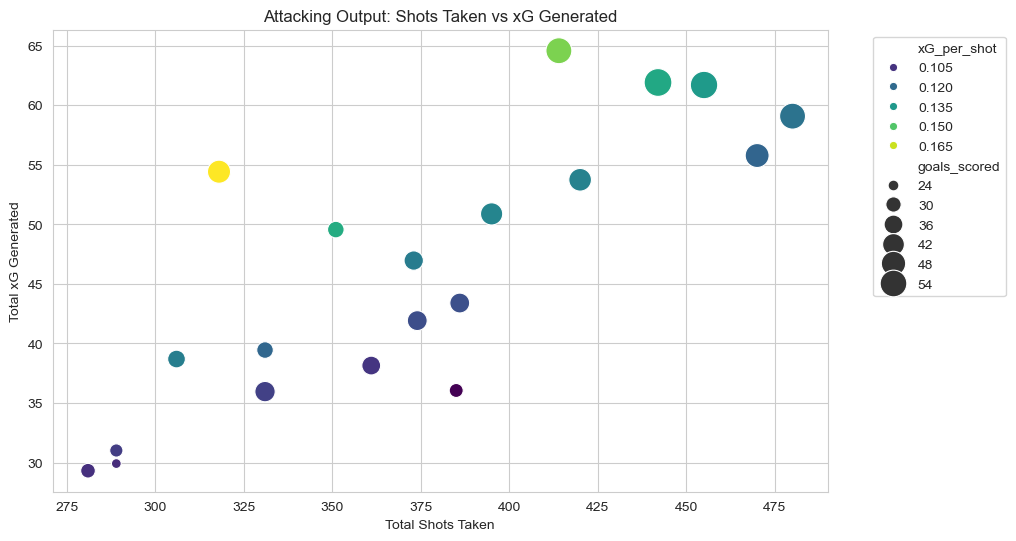


Attacking xG by Situation (Top 5 Creative Teams):
situation          DirectFreekick  FromCorner   OpenPlay   Penalty  SetPiece  \
attacking_team                                                                 
Liverpool                0.812876    6.564099  45.405101  1.522338  1.472672   
Manchester City          0.555734    8.349009  49.052597  3.044675  0.906521   
Nottingham Forest        0.617165    4.776012  27.655614  1.522338  1.483473   
Manchester United        0.482895    6.551853  45.164508  3.805844  3.076819   
Aston Villa              0.966189    6.567049  31.072559  0.000000  3.312683   

situation           total_xG  open_play_pct  
attacking_team                               
Liverpool          55.777086      81.404576  
Manchester City    61.908537      79.233979  
Nottingham Forest  36.054602      76.704810  
Manchester United  59.081919      76.443874  
Aston Villa        41.918480      74.126159  


In [74]:
# ---------------------------------------------------------
# QUESTION 2 (Extended): Teams/Attacks Generating xG
# ---------------------------------------------------------

# Determine which team took the shot
shotsdf['attacking_team'] = shotsdf.apply(lambda x: x['h_team'] if x['h_a'] == 'h' else x['a_team'], axis=1)

attacking_stats = shotsdf.groupby('attacking_team').agg({
    'xG': ['sum', 'count'],
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

attacking_stats.columns = ['team', 'xG_generated', 'shots_taken', 'goals_scored']

# Calculate quality per shot (xG per Shot)
attacking_stats['xG_per_shot'] = attacking_stats['xG_generated'] / attacking_stats['shots_taken']
attacking_stats = attacking_stats.sort_values(by='xG_generated', ascending=False)

print("\nAttacking Performance (xG Generated):")
print(attacking_stats.head())

# Plotting the relationship between shots taken and xG generated
plt.figure(figsize=(10,6))
sns.scatterplot(data=attacking_stats, x='shots_taken', y='xG_generated', hue='xG_per_shot', size='goals_scored', sizes=(50, 400), palette='viridis')
plt.title("Attacking Output: Shots Taken vs xG Generated")
plt.xlabel("Total Shots Taken")
plt.ylabel("Total xG Generated")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# ---------------------------------------------------------
# QUESTION 3 (Extended): Attacking Situations
# ---------------------------------------------------------

# Analyze which 'situation' creates the most xG for each team
attack_situation = shotsdf.groupby(['attacking_team', 'situation'])['xG'].sum().unstack().fillna(0)

# Calculate percentage of xG from Open Play to identify 'creative' vs 'set-piece' teams
attack_situation['total_xG'] = attack_situation.sum(axis=1)
attack_situation['open_play_pct'] = (attack_situation['OpenPlay'] / attack_situation['total_xG']) * 100

print("\nAttacking xG by Situation (Top 5 Creative Teams):")
print(attack_situation.sort_values(by='open_play_pct', ascending=False).head())

In [75]:
# Define 'Clutch' conditions: Minute 80+ and score difference <= 1
shotsdf['score_diff'] = abs(shotsdf['h_goals'] - shotsdf['a_goals'])
clutch_df = shotsdf[(shotsdf['minute'] >= 80) & (shotsdf['score_diff'] <= 1)].copy()

clutch_stats = clutch_df.groupby('player').agg({
    'xG': 'sum',
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

clutch_stats.columns = ['player', 'clutch_xG', 'clutch_goals']
clutch_stats['clutch_delta'] = clutch_stats['clutch_goals'] - clutch_stats['clutch_xG']

# Filter for players with at least 0.5 cumulative clutch xG to avoid small sample noise
top_clutch = clutch_stats[clutch_stats['clutch_xG'] > 0.5].sort_values(by='clutch_delta', ascending=False)

print("Top 5 'Clutch' Finishers (Late Game Overperformers):")
print(top_clutch.head())

Top 5 'Clutch' Finishers (Late Game Overperformers):
                 player  clutch_xG  clutch_goals  clutch_delta
220       Mohamed Salah   1.454233             3      1.545767
259         Richarlison   1.625489             3      1.374511
308       William Osula   0.665667             2      1.334333
134  Jan Paul van Hecke   0.841736             2      1.158264
21       Benjamin Sesko   0.844359             2      1.155641


In [76]:
# Filter out shots with no assisted player (NaN)
supply_line = shotsdf.dropna(subset=['player_assisted'])

# Aggregate xG by Passer -> Shooter pairs
pairs = supply_line.groupby(['player_assisted', 'player']).agg({
    'xG': 'sum',
    'result': lambda x: (x == 'Goal').sum()
}).reset_index()

pairs.columns = ['passer', 'shooter', 'total_xG_created', 'actual_goals']
pairs = pairs.sort_values(by='total_xG_created', ascending=False)

print("\nTop 5 Most Dangerous Partnerships (By xG Created):")
print(pairs.head(5))

# Optional: Find the 'Main Provider' for a specific player (e.g., Gyökeres)
target_player = 'Viktor Gyokeres'
provider = pairs[pairs['shooter'] == target_player].sort_values(by='total_xG_created', ascending=False)

print(f"\nWho feeds {target_player} the best chances?")
print(provider.head(3))


Top 5 Most Dangerous Partnerships (By xG Created):
              passer         shooter  total_xG_created  actual_goals
1812   Mathis Cherki  Erling Haaland          3.628544             2
1480    Kevin Schade          Thiago          2.910977             3
2228      Phil Foden  Erling Haaland          2.665958             1
252   Bernardo Silva  Erling Haaland          2.504374             1
1990   Morgan Rogers   Ollie Watkins          2.456526             2

Who feeds Viktor Gyokeres the best chances?
                  passer          shooter  total_xG_created  actual_goals
374          Bukayo Saka  Viktor Gyokeres          1.318218             0
914   Gabriel Martinelli  Viktor Gyokeres          1.091324             2
1552    Leandro Trossard  Viktor Gyokeres          0.972572             0
